In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Binarizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datetime import datetime
import os

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)


Загрузка и подготовка данных

In [5]:
DATA_PATH = 'heart.csv'

df = pd.read_csv(DATA_PATH)
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


В работе используется датасет heart.csv (Heart Failure Prediction), содержащий медицинские показатели пациентов.

Целевая переменная — HeartDisease (1 — наличие сердечного заболевания, 0 — отсутствие).

Набор данных содержит как числовые, так и категориальные признаки, поэтому перед обучением моделей требуется:
- обработка категориальных признаков (One-Hot Encoding),
- масштабирование числовых признаков,
- корректная обработка «технических нулей» в отдельных столбцах (например, Cholesterol = 0 может означать отсутствие измерения). Чтобы не искажать обучение, заменим такие нули на NaN и далее будем заполнять медианой.


In [8]:
df = df.copy()
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = np.nan
df.loc[df['RestingBP'] == 0, 'RestingBP'] = np.nan

print("Размер:", df.shape)
print("\nПропуски после замены нулей на NaN:")
display(df[['Cholesterol','RestingBP']].isna().sum())

print("\nРаспределение классов HeartDisease:")
display(df['HeartDisease'].value_counts().to_frame('count').assign(share=lambda x: x['count']/x['count'].sum()))
df.head()


Размер: (918, 12)

Пропуски после замены нулей на NaN:


Cholesterol    172
RestingBP        1
dtype: int64


Распределение классов HeartDisease:


,count,share
HeartDisease,,
1,508,0.553377
0,410,0.446623


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


Признаки:

Числовые: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`

Категориальные: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`

Замечания по подготовке данных:
- SVM/kNN/нейросети чувствительны к масштабу → применяем `StandardScaler` к числовым признакам.
- `MultinomialNB` / `ComplementNB` требуют неотрицательные признаки → применяем `MinMaxScaler`.
- Для категориальных признаков используем `OneHotEncoder`.
- Пропуски в числовых столбцах заполняем медианой (`SimpleImputer(strategy='median')`), в категориальных — самым частым значением.


In [10]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

num_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']
cat_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
X_train.shape, X_test.shape


((688, 11), (230, 11))

Метрики

In [11]:
def get_scores_for_auc(model, X):
    """Возвращает скор для ROC: predict_proba[:,1] или decision_function."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_score = get_scores_for_auc(model, X_test)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_score),
    }
    fpr, tpr, _ = roc_curve(y_test, y_score)
    return metrics, (fpr, tpr)

def plot_roc(curves, title='ROC curves'):
    plt.figure(figsize=(7,5))
    for name, (fpr, tpr) in curves.items():
        plt.plot(fpr, tpr, label=name)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

Модели Baseline:

Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);

Деревья решений (Decision Tree);

Линейный дискриминантный анализ (Linear Discriminant Analysis);

Метод опорных векторов (Support Vector Machines);

Метод ближайших соседей (k-Nearest Neighbors);


In [13]:
num_std = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_minmax = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

cat_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess_std = ColumnTransformer([
    ('num', num_std, num_cols),
    ('cat', cat_ohe, cat_cols)
])

preprocess_minmax = ColumnTransformer([
    ('num', num_minmax, num_cols),
    ('cat', cat_ohe, cat_cols)
])

preprocess_minmax_dense = preprocess_minmax


In [14]:
models = {
    'GaussianNB': Pipeline([
        ('prep', preprocess_std),
        ('clf', GaussianNB())
    ]),
    'MultinomialNB': Pipeline([
        ('prep', preprocess_minmax),
        ('clf', MultinomialNB())
    ]),
    'ComplementNB': Pipeline([
        ('prep', preprocess_minmax),
        ('clf', ComplementNB())
    ]),
    'BernoulliNB': Pipeline([
        ('prep', preprocess_minmax_dense),
        ('bin', Binarizer(threshold=0.5)),
        ('clf', BernoulliNB())
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocess_std),
        ('clf', DecisionTreeClassifier(random_state=SEED))
    ]),
    'LDA': Pipeline([
        ('prep', preprocess_std),
        ('clf', LinearDiscriminantAnalysis())
    ]),
    'SVM': Pipeline([
        ('prep', preprocess_std),
        ('clf', SVC(kernel='rbf', probability=True, random_state=SEED))
    ]),
    'kNN': Pipeline([
        ('prep', preprocess_std),
        ('clf', KNeighborsClassifier())
    ])
}

rows = []
curves = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    m, (fpr, tpr) = evaluate_model(name, model, X_test, y_test)
    rows.append(m)
    curves[name] = (fpr, tpr)

baseline = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False)
baseline

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
6,SVM,0.860870,0.846715,0.913386,0.878788,0.918966
5,LDA,0.856522,0.867188,0.874016,0.870588,0.918278
3,BernoulliNB,0.847826,0.870968,0.850394,0.860558,0.915259
1,MultinomialNB,0.856522,0.879032,0.858268,0.868526,0.915068
2,ComplementNB,0.860870,0.886179,0.858268,0.872000,0.915068
0,GaussianNB,0.830435,0.849206,0.842520,0.845850,0.908875
7,kNN,0.843478,0.837037,0.889764,0.862595,0.899243
4,DecisionTree,0.773913,0.815126,0.763780,0.788618,0.775094


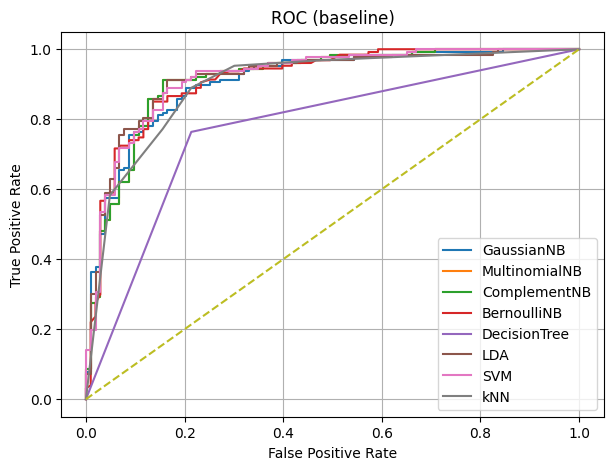

In [15]:
plot_roc(curves, title='ROC (baseline)')

На ROC-графике видно, что почти все модели (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB, LDA, SVM, kNN) дают очень близкие кривые, которые проходят вплотную к левому верхнему углу. Уже при FPR ≈ 0.1–0.2 достигается TPR ≈ 0.85–0.95, то есть классификаторы хорошо отделяют классы даже при небольшом количестве ложных срабатываний — AUC у большинства методов высокий и различия между ними небольшие.

На этом фоне Decision Tree заметно уступает: его кривая проходит существенно ниже остальных (особенно в области малых FPR), что связано с тем, что одиночное дерево без аккуратной регуляризации/настроек даёт более “рваную” и менее устойчивую границу, из-за чего обобщающая способность хуже. В итоге по ROC-AUC лидируют/идут почти наравне LDA/SVM/kNN и байесовские модели.


Настройка гиперпараметров 

Для сопоставимости оптимизируем по AUC-ROC. Потом оцениваем лучшую модель на test.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grids = {
    'GaussianNB': {
        'clf__var_smoothing': np.logspace(-12, -6, 7)
    },
    'MultinomialNB': {
        'clf__alpha': [0.01, 0.1, 1.0, 5.0],
        'clf__fit_prior': [True, False]
    },
    'ComplementNB': {
        'clf__alpha': [0.01, 0.1, 1.0, 5.0],
        'clf__norm': [True, False]
    },
    'BernoulliNB': {
        'bin__threshold': [0.3, 0.5, 0.7],
        'clf__alpha': [0.01, 0.1, 1.0, 5.0]
    },
    'DecisionTree': {
        'clf__max_depth': [None, 3, 5, 8, 12],
        'clf__min_samples_split': [2, 5, 10, 20],
        'clf__min_samples_leaf': [1, 2, 5, 10],
        'clf__criterion': ['gini', 'entropy', 'log_loss']
    },
    # shrinkage корректно применяется только для solver='lsqr'
    'LDA': [
        {'clf__solver': ['svd'], 'clf__shrinkage': [None]},
        {'clf__solver': ['lsqr'], 'clf__shrinkage': [None, 'auto', 0.0, 0.1, 0.5]}
    ],
    'SVM': {
        'clf__C': [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 0.01, 0.1, 1.0]
    },
    'kNN': {
        'clf__n_neighbors': [3, 5, 7, 11, 15, 21],
        'clf__weights': ['uniform', 'distance'],
        'clf__p': [1, 2]
    }
}

tuned_rows = []
tuned_curves = {}
best_estimators = {}

for name, model in models.items():
    print(f'Tuning: {name}')
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    best_estimators[name] = best

    m, (fpr, tpr) = evaluate_model(name + ' (tuned)', best, X_test, y_test)
    m['CV_AUC'] = gs.best_score_
    m['BestParams'] = gs.best_params_
    tuned_rows.append(m)
    tuned_curves[name + ' (tuned)'] = (fpr, tpr)

tuned = pd.DataFrame(tuned_rows).sort_values('AUC-ROC', ascending=False)
tuned


Tuning: GaussianNB
Tuning: MultinomialNB
Tuning: ComplementNB
Tuning: BernoulliNB
Tuning: DecisionTree
Tuning: LDA
Tuning: SVM
Tuning: kNN


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,CV_AUC,BestParams
6,SVM (tuned),0.865217,0.858209,0.905512,0.881226,0.919043,0.924296,"{'clf__C': 10, 'clf__gamma': 0.01}"
5,LDA (tuned),0.860870,0.874016,0.874016,0.874016,0.917208,0.922618,"{'clf__shrinkage': 0.1, 'clf__solver': 'lsqr'}"
3,BernoulliNB (tuned),0.847826,0.870968,0.850394,0.860558,0.915182,0.921766,"{'bin__threshold': 0.5, 'clf__alpha': 5.0}"
1,MultinomialNB (tuned),0.856522,0.879032,0.858268,0.868526,0.914762,0.918973,"{'clf__alpha': 5.0, 'clf__fit_prior': True}"
2,ComplementNB (tuned),0.860870,0.886179,0.858268,0.872000,0.914762,0.918973,"{'clf__alpha': 5.0, 'clf__norm': False}"
7,kNN (tuned),0.860870,0.857143,0.897638,0.876923,0.913730,0.922272,"{'clf__n_neighbors': 21, 'clf__p': 1, 'clf__we..."
4,DecisionTree (tuned),0.830435,0.872881,0.811024,0.840816,0.913653,0.897720,"{'clf__criterion': 'gini', 'clf__max_depth': 3..."
0,GaussianNB (tuned),0.830435,0.849206,0.842520,0.845850,0.908875,0.910382,{'clf__var_smoothing': 1e-12}


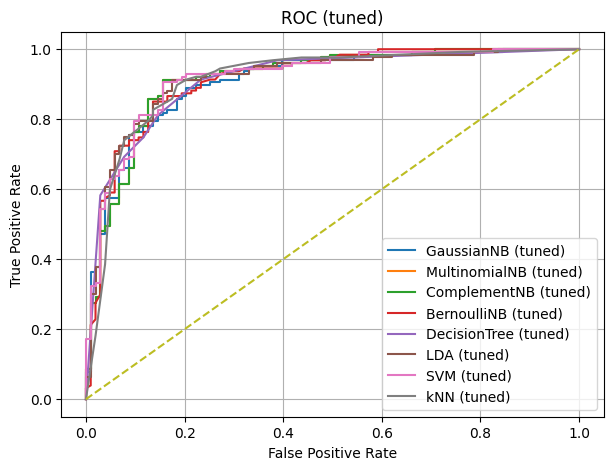

In [19]:
plot_roc(tuned_curves, title='ROC (tuned)')

Настройка гиперпараметров существенно улучшила качество модели, склонной к переобучению, а именно Decision Tree. Однако для остальных моделей улучшения оказались незначительными, что говорит о близости baseline-параметров к оптимальным.


Сравнение baseline и tuned

In [20]:
tuned1 = tuned.copy()
tuned1['Model'] = tuned1['Model'].str.replace(' (tuned)', '', regex=False)

compare = baseline.merge(
    tuned1[['Model','Accuracy','Precision','Recall','F1','AUC-ROC']],
    on='Model',
    how='left',
    suffixes=('_baseline','_tuned')
)
compare

,Model,Accuracy_baseline,Precision_baseline,Recall_baseline,F1_baseline,AUC-ROC_baseline,Accuracy_tuned,Precision_tuned,Recall_tuned,F1_tuned,AUC-ROC_tuned
0,SVM,0.860870,0.846715,0.913386,0.878788,0.918966,0.865217,0.858209,0.905512,0.881226,0.919043
1,LDA,0.856522,0.867188,0.874016,0.870588,0.918278,0.860870,0.874016,0.874016,0.874016,0.917208
2,BernoulliNB,0.847826,0.870968,0.850394,0.860558,0.915259,0.847826,0.870968,0.850394,0.860558,0.915182
3,MultinomialNB,0.856522,0.879032,0.858268,0.868526,0.915068,0.856522,0.879032,0.858268,0.868526,0.914762
4,ComplementNB,0.860870,0.886179,0.858268,0.872000,0.915068,0.860870,0.886179,0.858268,0.872000,0.914762
5,GaussianNB,0.830435,0.849206,0.842520,0.845850,0.908875,0.830435,0.849206,0.842520,0.845850,0.908875
6,kNN,0.843478,0.837037,0.889764,0.862595,0.899243,0.860870,0.857143,0.897638,0.876923,0.913730
7,DecisionTree,0.773913,0.815126,0.763780,0.788618,0.775094,0.830435,0.872881,0.811024,0.840816,0.913653


Наилучшие значения по метрике AUC-ROC показали:

SVM — 0.919

LDA — 0.9183

BernoulliNB — 0.9153

Различия между ними минимальны, что говорит о высокой линейной разделимости данных.

Наибольший прирост качества наблюдается у:

Decision Tree

AUC: 0.7751 → 0.9137

Accuracy: 0.7739 → 0.8304

Улучшение связано с ограничением глубины и контролем переобучения, в результате переобучение уменьшается и резко улучшается обобщение.

kNN

AUC: 0.8992 → 0.9137

Accuracy: 0.8435 → 0.8609

Настройка числа соседей/весов помогает стабилизировать решение и повысить качество.

У линейных/байесовских моделей изменения минимальны:

SVM улучшился совсем чуть-чуть по AUC/Accuracy.

LDA по AUC слегка просел (это нормально: настройка могла лучше “подогнать” точность/F1, но не AUC).

GaussianNB и остальные NB-варианты почти не изменились (значит baseline уже близок к оптимальному для них).

Accuracy у большинства моделей находится в диапазоне 0.85–0.87.

Precision и Recall достаточно сбалансированы, что говорит об отсутствии сильного перекоса в сторону одного класса.


Тестирование на TensorFlow


In [21]:
prep_for_nn = preprocess_std
X_train_nn = prep_for_nn.fit_transform(X_train)
X_test_nn = prep_for_nn.transform(X_test)

if hasattr(X_train_nn, 'toarray'):
    X_train_nn = X_train_nn.toarray()
    X_test_nn = X_test_nn.toarray()

X_train_nn.shape, X_test_nn.shape

((688, 20), (230, 20))

In [22]:
def build_mlp(input_dim, lr=1e-3, arch="B", dropout=0.2):
    if arch == "A":
        hidden = [8]
    elif arch == "B":
        hidden = [8, 16]
    else:  # "C"
        hidden = [32, 32]

    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for u in hidden:
        model.add(layers.Dense(u, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

def summarize_history(hist, last_k=5):
    mean_val_auc = float(np.mean(hist.history["val_auc"][-last_k:]))
    mean_val_acc = float(np.mean(hist.history["val_accuracy"][-last_k:]))
    mean_val_loss = float(np.mean(hist.history["val_loss"][-last_k:]))
    best_val_auc = float(np.max(hist.history["val_auc"]))
    return mean_val_auc, mean_val_acc, mean_val_loss, best_val_auc

base_logdir = os.path.join("logs", "tf_studies", datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(base_logdir, exist_ok=True)

def plot_history(history, title_prefix=""):
    # Loss
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} | Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    plt.figure(figsize=(7,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} | Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

Исследование архитектуры

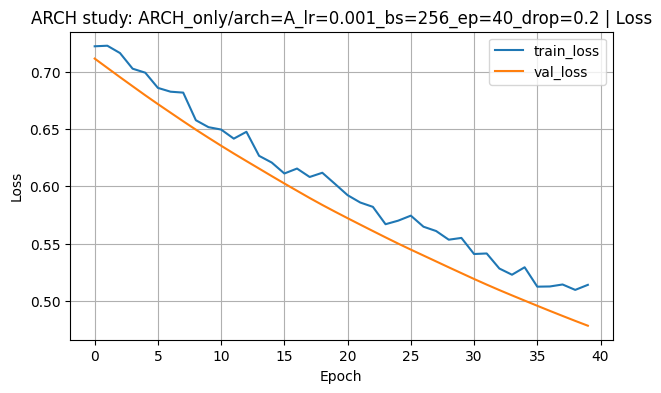

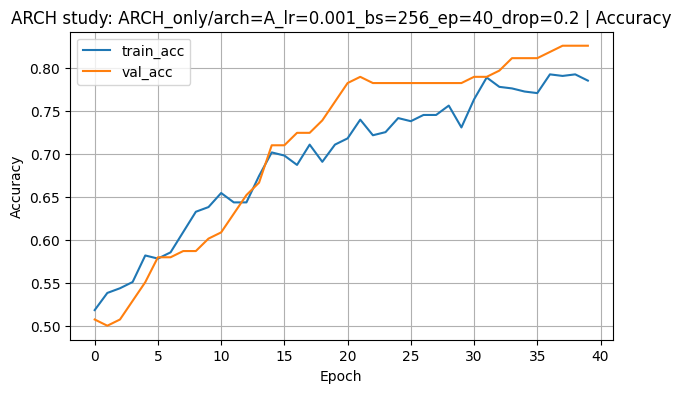

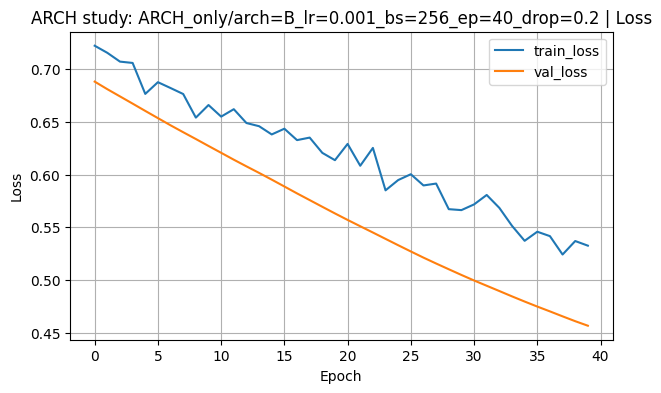

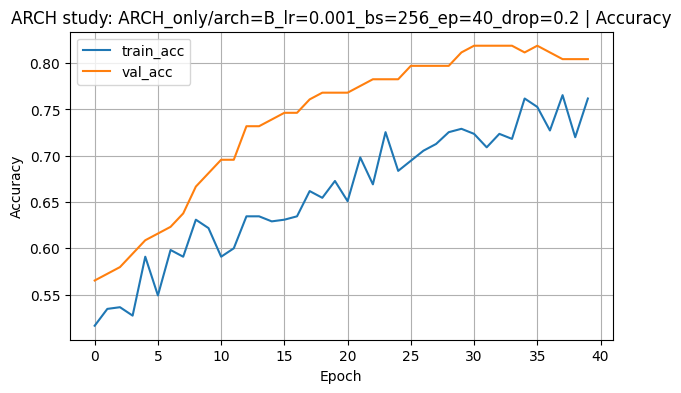

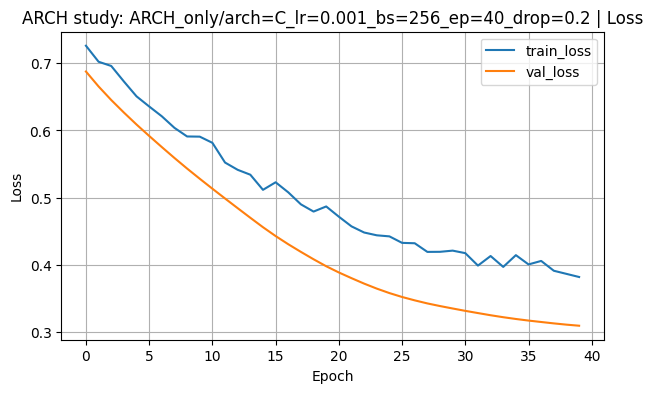

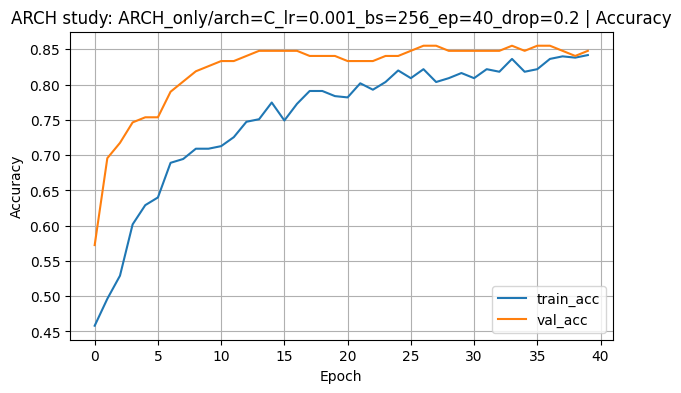

,arch,lr,batch_size,epochs,dropout,mean_val_auc_last5,mean_val_acc_last5,best_val_auc,test_auc,test_acc
2,C,0.001,256,40,0.2,0.944779,0.849275,0.946095,0.901842,0.830435
1,B,0.001,256,40,0.2,0.887394,0.808696,0.891023,0.851693,0.769565
0,A,0.001,256,40,0.2,0.884402,0.821739,0.888688,0.843552,0.795652


In [23]:
archs = ["A", "B", "C"]
LR = 1e-3
BATCH = 256
EPOCHS = 40
DROP = 0.2

results_arch = []

for arch in archs:
    run_name = f"ARCH_only/arch={arch}_lr={LR}_bs={BATCH}_ep={EPOCHS}_drop={DROP}"
    logdir = os.path.join(base_logdir, run_name)

    callbacks = [
        keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=0),
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True)
    ]

    model = build_mlp(X_train_nn.shape[1], lr=LR, arch=arch, dropout=DROP)

    hist = model.fit(
        X_train_nn, y_train.values,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=callbacks,
        verbose=0
    )

    mean_val_auc, mean_val_acc, mean_val_loss, best_val_auc = summarize_history(hist, last_k=5)
    test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test.values, verbose=0)
    plot_history(hist, title_prefix=f"ARCH study: {run_name}")
    
    results_arch.append({
        "arch": arch,
        "lr": LR,
        "batch_size": BATCH,
        "epochs": EPOCHS,
        "dropout": DROP,
        "mean_val_auc_last5": mean_val_auc,
        "mean_val_acc_last5": mean_val_acc,
        "best_val_auc": best_val_auc,
        "test_auc": float(test_auc),
        "test_acc": float(test_acc),
    })

df_arch = pd.DataFrame(results_arch).sort_values(["test_auc","test_acc"], ascending=False)
df_arch

Архитектура C показала лучшие значения, при этом валидация высокая и стабильная. Это самый сильный и при этом устойчивый вариант.

Архитектура B заметно хуже. По сути сеть слабее/хуже обобщает, похоже на недообучение.

Архитектура A тоже хуже, чем C. Также выглядит как недообучение по сравнению с лучшим вариантом.

Следовательно, архитектура C является наиболее предпочтительной для данного датасета. Это означает, что выбранная модель обладает достаточной выразительной способностью, но при этом не проявляет явных признаков переобучения, поэтому именно архитектура C обеспечивает наиболее надёжное обобщение на новых данных.

Исследование Learning rate

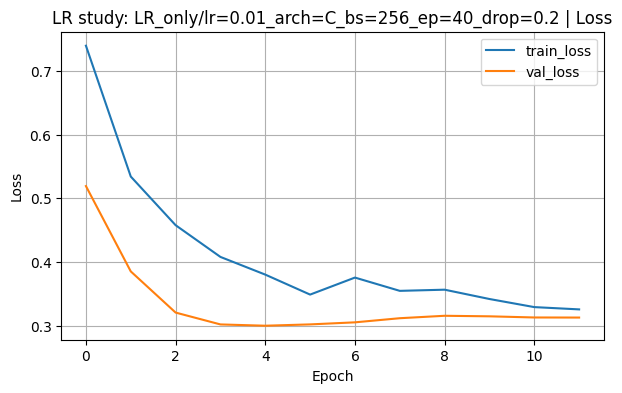

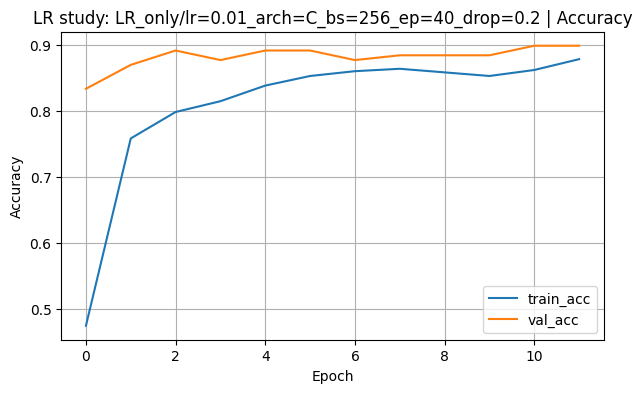

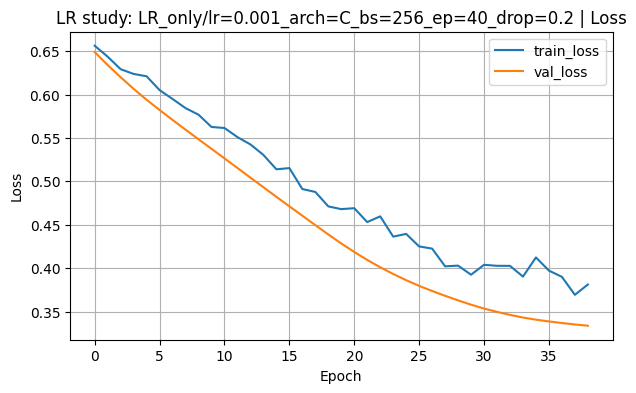

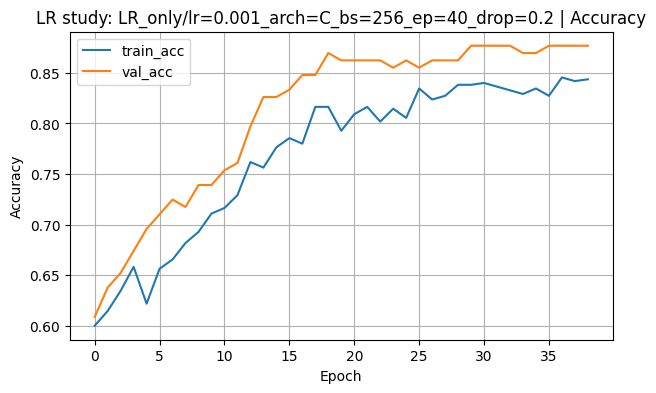

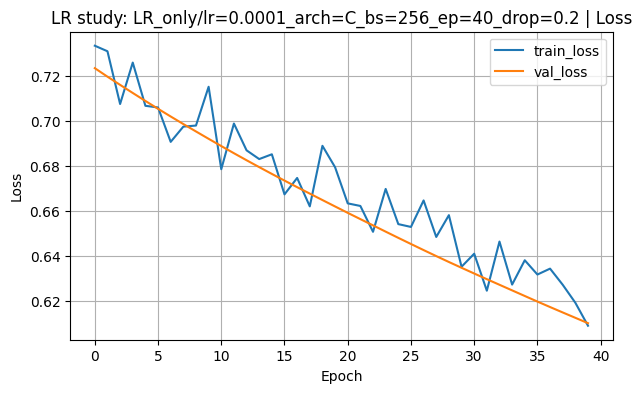

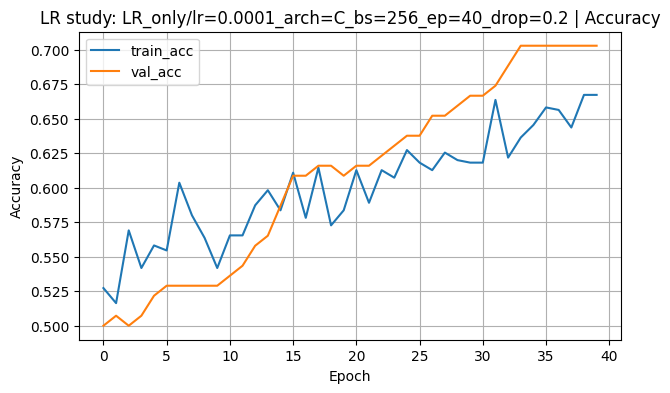

,lr,arch,batch_size,epochs,dropout,mean_val_auc_last5,mean_val_acc_last5,best_val_auc,test_auc,test_acc
0,0.0100,C,256,40,0.2,0.939771,0.889855,0.943336,0.912239,0.847826
1,0.0010,C,256,40,0.2,0.931430,0.875362,0.931876,0.902377,0.813043
2,0.0001,C,256,40,0.2,0.775700,0.702899,0.782152,0.823637,0.752174


In [26]:
lrs = [1e-2, 1e-3, 1e-4]
ARCH = "C"
BATCH = 256
EPOCHS = 40
DROP = 0.2

results_lr = []

for lr in lrs:
    run_name = f"LR_only/lr={lr}_arch={ARCH}_bs={BATCH}_ep={EPOCHS}_drop={DROP}"
    logdir = os.path.join(base_logdir, run_name)

    callbacks = [
        keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=0),
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True)
    ]

    model = build_mlp(X_train_nn.shape[1], lr=lr, arch=ARCH, dropout=DROP)

    hist = model.fit(
        X_train_nn, y_train.values,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=callbacks,
        verbose=0
    )

    mean_val_auc, mean_val_acc, mean_val_loss, best_val_auc = summarize_history(hist, last_k=5)
    test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test.values, verbose=0)
    plot_history(hist, title_prefix=f"LR study: {run_name}")

    results_lr.append({
        "lr": lr,
        "arch": ARCH,
        "batch_size": BATCH,
        "epochs": EPOCHS,
        "dropout": DROP,
        "mean_val_auc_last5": mean_val_auc,
        "mean_val_acc_last5": mean_val_acc,
        "best_val_auc": best_val_auc,
        "test_auc": float(test_auc),
        "test_acc": float(test_acc),
    })

df_lr = pd.DataFrame(results_lr).sort_values(["test_auc","test_acc"], ascending=False)
df_lr

При слишком малом learning rate (0.0001) модель обучается слишком медленно и не достигает оптимума за заданное число эпох, что приводит к ухудшению качества.

Значения 0.01 и 0.001 обеспечивают стабильное обучение. Наилучший результат достигнут при lr = 0.01.

Исследование Batch size

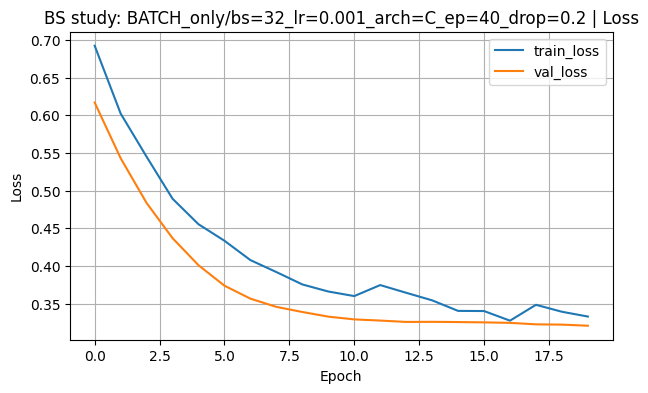

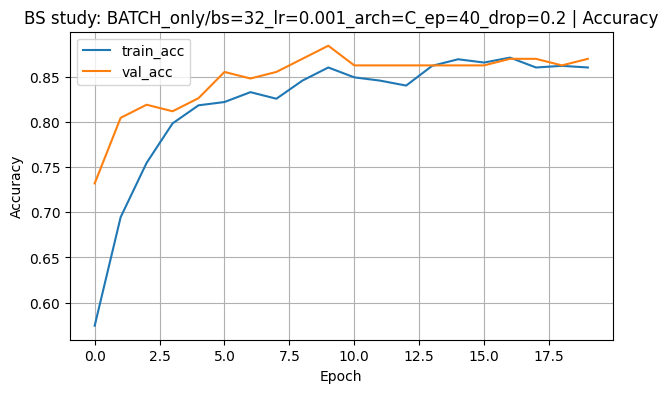

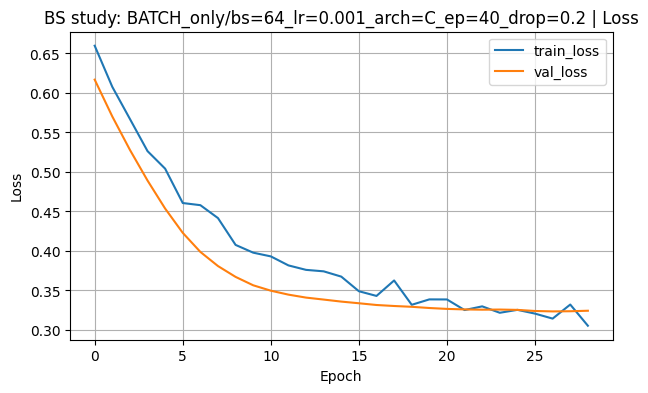

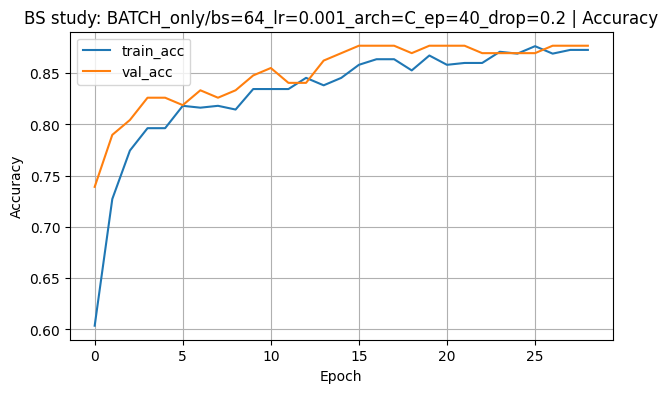

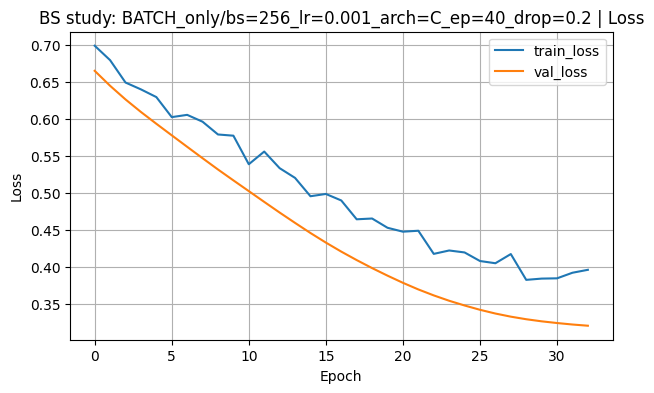

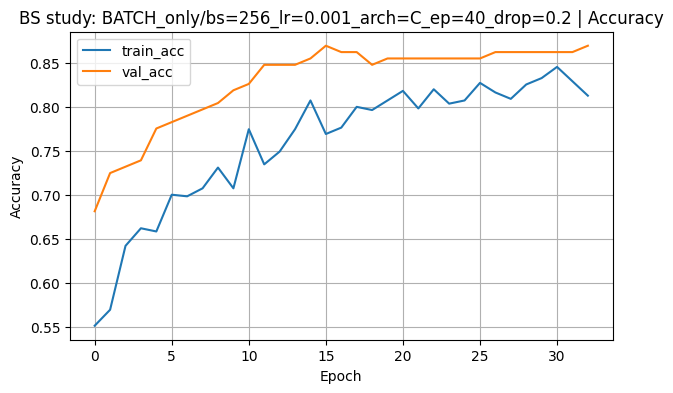

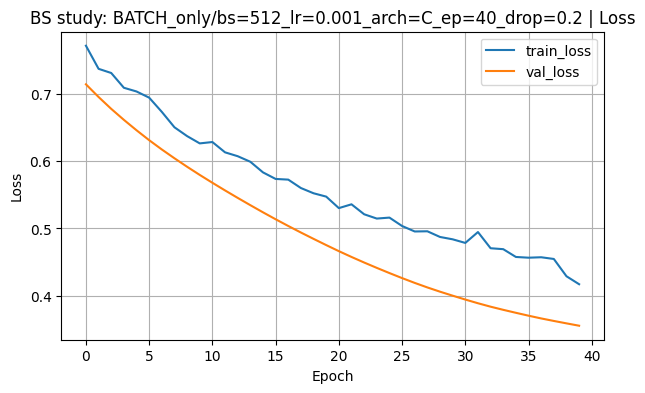

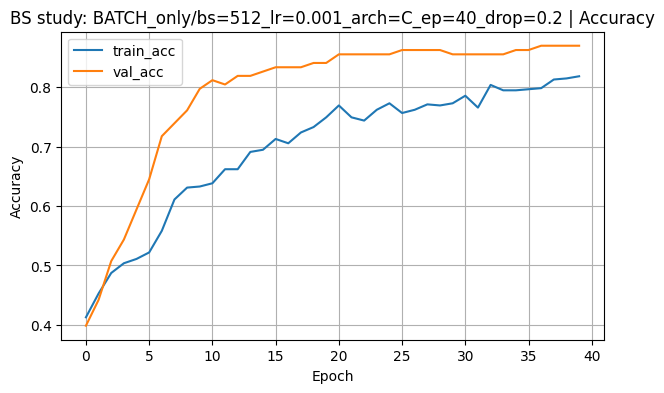

,batch_size,lr,arch,epochs,dropout,mean_val_auc_last5,mean_val_acc_last5,best_val_auc,test_auc,test_acc
1,64,0.001,C,40,0.2,0.933383,0.873913,0.933998,0.910060,0.856522
2,256,0.001,C,40,0.2,0.936778,0.863768,0.938455,0.906047,0.817391
0,32,0.001,C,40,0.2,0.932640,0.866667,0.934211,0.904824,0.834783
3,512,0.001,C,40,0.2,0.934041,0.868116,0.934953,0.895994,0.800000


In [27]:
batch_sizes = [32, 64, 256, 512]
LR = 1e-3
ARCH = "C"
EPOCHS = 40
DROP = 0.2

results_bs = []

for bs in batch_sizes:
    run_name = f"BATCH_only/bs={bs}_lr={LR}_arch={ARCH}_ep={EPOCHS}_drop={DROP}"
    logdir = os.path.join(base_logdir, run_name)

    callbacks = [
        keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=0),
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True)
    ]

    model = build_mlp(X_train_nn.shape[1], lr=LR, arch=ARCH, dropout=DROP)

    hist = model.fit(
        X_train_nn, y_train.values,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=bs,
        callbacks=callbacks,
        verbose=0
    )

    mean_val_auc, mean_val_acc, mean_val_loss, best_val_auc = summarize_history(hist, last_k=5)
    test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test.values, verbose=0)
    plot_history(hist, title_prefix=f"BS study: {run_name}")

    results_bs.append({
        "batch_size": bs,
        "lr": LR,
        "arch": ARCH,
        "epochs": EPOCHS,
        "dropout": DROP,
        "mean_val_auc_last5": mean_val_auc,
        "mean_val_acc_last5": mean_val_acc,
        "best_val_auc": best_val_auc,
        "test_auc": float(test_auc),
        "test_acc": float(test_acc),
    })

df_bs = pd.DataFrame(results_bs).sort_values(["test_auc","test_acc"], ascending=False)
df_bs

В рассматриваемом диапазоне batch size оказывает ограниченное влияние на качество: AUC-ROC остаётся практически стабильной. Accuracy меняется сильнее. В среднем качество сопоставимо, но по accuracy лучший результат у batch_size=64.

Исследование количества эпох

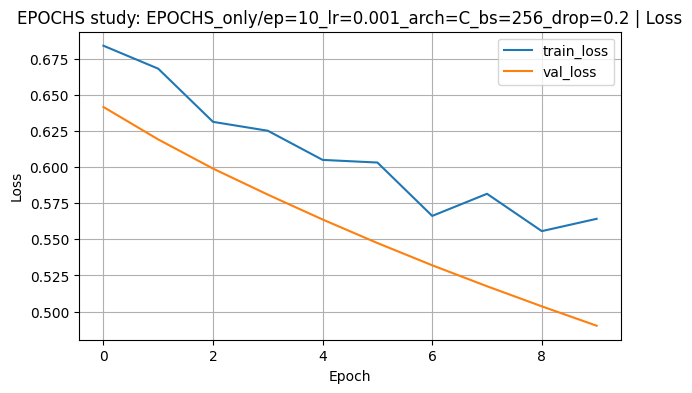

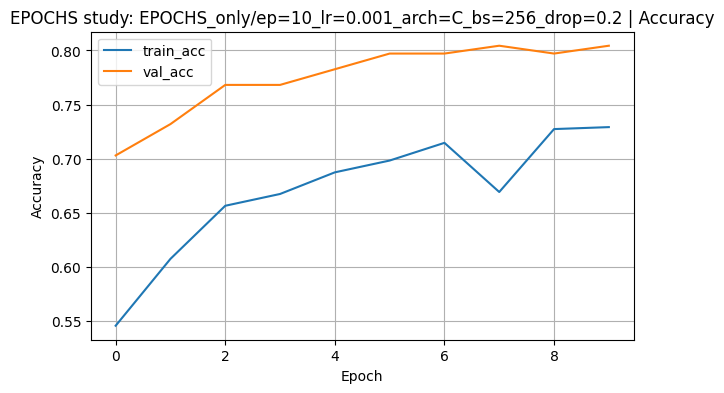

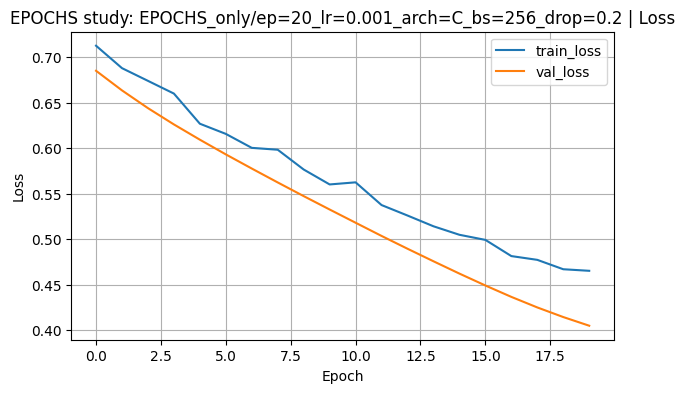

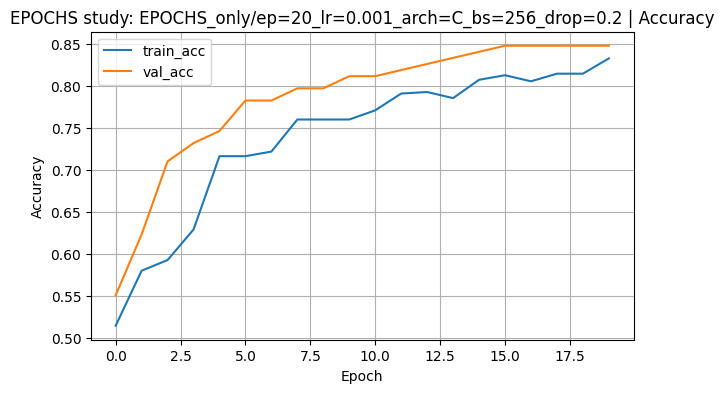

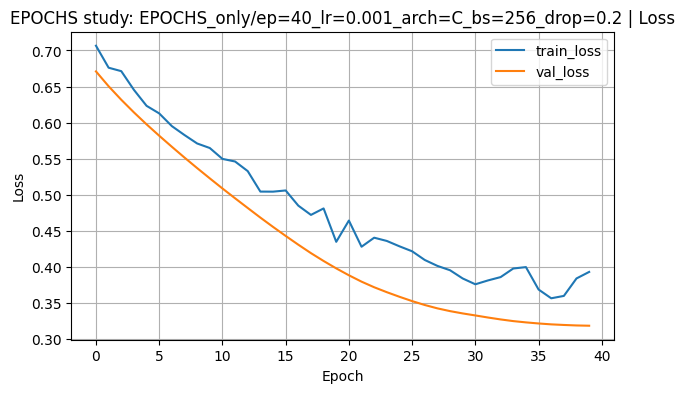

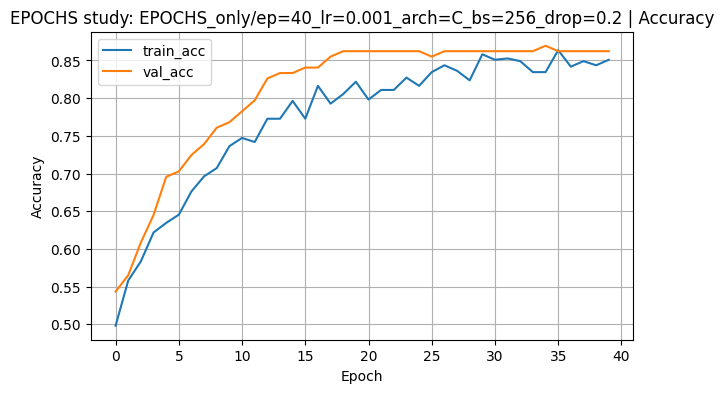

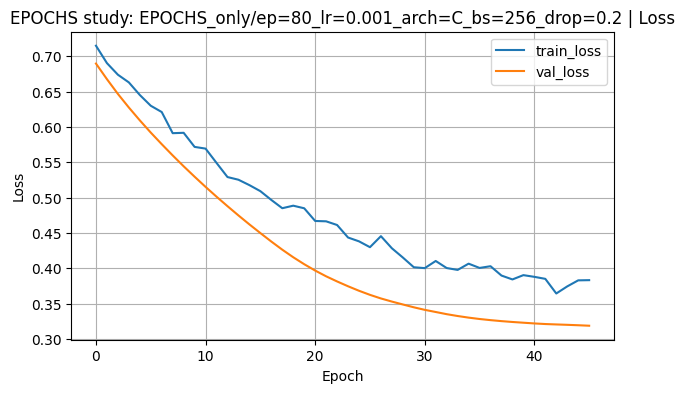

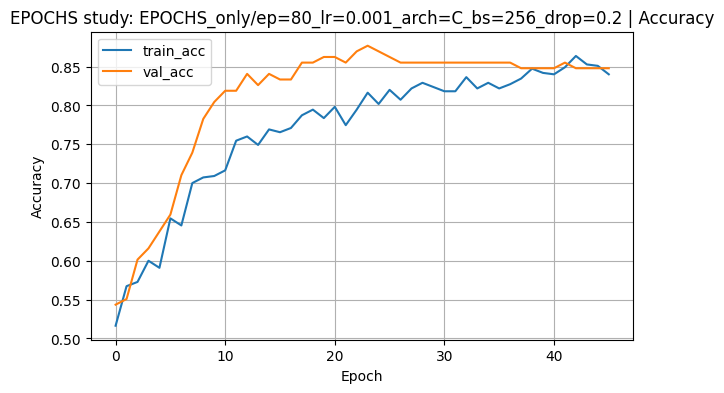

,epochs,lr,arch,batch_size,dropout,mean_val_auc_last5,mean_val_acc_last5,best_val_auc,test_auc,test_acc
2,40,0.001,C,256,0.2,0.941193,0.862319,0.941426,0.915374,0.847826
3,80,0.001,C,256,0.2,0.936672,0.849275,0.937606,0.907614,0.826087
1,20,0.001,C,256,0.2,0.910484,0.847826,0.915747,0.887814,0.821739
0,10,0.001,C,256,0.2,0.887458,0.800000,0.899194,0.873404,0.752174


In [28]:
epochs_list = [10, 20, 40, 80]
LR = 1e-3
ARCH = "C"
BATCH = 256
DROP = 0.2

results_ep = []

for ep in epochs_list:
    run_name = f"EPOCHS_only/ep={ep}_lr={LR}_arch={ARCH}_bs={BATCH}_drop={DROP}"
    logdir = os.path.join(base_logdir, run_name)

    callbacks = [
        keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=0),
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=7, restore_best_weights=True)
    ]

    model = build_mlp(X_train_nn.shape[1], lr=LR, arch=ARCH, dropout=DROP)

    hist = model.fit(
        X_train_nn, y_train.values,
        validation_split=0.2,
        epochs=ep,
        batch_size=BATCH,
        callbacks=callbacks,
        verbose=0
    )

    mean_val_auc, mean_val_acc, mean_val_loss, best_val_auc = summarize_history(hist, last_k=5)
    test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test.values, verbose=0)
    plot_history(hist, title_prefix=f"EPOCHS study: {run_name}")

    results_ep.append({
        "epochs": ep,
        "lr": LR,
        "arch": ARCH,
        "batch_size": BATCH,
        "dropout": DROP,
        "mean_val_auc_last5": mean_val_auc,
        "mean_val_acc_last5": mean_val_acc,
        "best_val_auc": best_val_auc,
        "test_auc": float(test_auc),
        "test_acc": float(test_acc),
    })

df_ep = pd.DataFrame(results_ep).sort_values(["test_auc","test_acc"], ascending=False)
df_ep

Разумно выбирать около 40 эпох. При 10 эпохах наблюдается недообучение. 80 эпох уже не улучшает и может ухудшать качество на тесте, что, возможно является началом переобучения.